<a href="https://colab.research.google.com/github/syifaymd/Pratikum-Analisis-Deret-Waktu/blob/main/Kelompok_7_Minggu_5_Pemodelan_Data_Deret_Waktu_Stasioner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center> PEMODELAN DERET WAKTU STASIONER</center></h1>
<h1><left>Kelompok 7 : <left></h1>

1.   Nur Jannah Tuasikal (M0501251002)
2.   Rismawati Saputri (A2502251012)
3.   Syifa Ul Qalbi YMD (M0501251026)
4.   Estyaningsi Purnama (M0501251058)
____________________________________________________________________________________________________________________________
</center>


##TUGAS KELOMPOK

Lakukan simulasi deret stasioner. Gunakan seed jumlah 2 digit terakhir semua anggota kelompok.

1. Simulasikan deret MA (1) deret parameter $\theta=0.6$ dan panjang amatan 120.

2. Lakukan pembagian data latih dan data uji terhadap deret hasil simulasi (proporsi pembagian data bebas, sesuaikan dengan pola deret).

3. Buatlah plot ACF, PACF, dan EACF dari data latih. Identifikasi model yang tepat untuk deret simulasi berdasarkan plot-plot tersebut, kemudian lakukan pengepasan model terhadap data latij.

4. Lakukan pengecekan diagnostik sisaan model, overfitting, dan tentukan model terbaik berdasarkan kriteria AIC dan BIC.

5. Gunakan model terbaik untuk melakukan peramalan sepanjang periode data uji. Hitunglah metrik evaluasi MAPE dan RMSE dari hasil peramalan dan data latih maupun data uji. Interpretasikan apakah model yang digunakan sudah baik.

6. Lakukan tahapan 2-5 dengan deret simulasi yang berbeda, yaitu deret AR(2) dengan $n=100$ dan parameter $\phi_1=0.9$ dan $\phi_2=-0.5$; deret ARMA(1,1) dengan $n=200$ dan parameter $\phi=0.4$ dan $\theta=0.6$.

Pengumpulan hasil diskusi:

- melalui class.ipb.ac.id cukup perwakilan kelompok dengan format pdf. Dalam file tersebut memuat identitas anggota kelompok (Nama, NIM). Dalam file tidak perlu mencantumkan sintaks, namun menampilkan plot deret waktu dari deret simulasi dan interpretasinya; pembagian data latih data uji dan alasan pemilihan pembagian data; plot ACF, PACF, EACF, dan interpretasinya; hasil pengepasan model dan diagnostik sisaan model dan interpretasinya; plot hasil peramalan dan deret asli, nilai metrik evaluasi, dan interpretasinya.

- melalui github masing-masing anggota kelompok berupa file sintaks.

#Impor Pustaka & Pengaturan Seed

In [ ]:
!pip install PythonTsa

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf

# Gunakan seed dari jumlah 2 digit terakhir NIM anggota kelompok (misal diset 42 atau sesuaikan)
seed_value = 98
np.random.seed(seed_value)

#Nomor 1 - 5 : Simulasi Deret MA(1) [θ = 0.6, n = 120]

### 1. Simulasi Deret

In [ ]:
ar_ma1 = [1]
ma_ma1 = [1, 0.6]
ma1_process = ArmaProcess(ar_ma1, ma_ma1)
y_ma1 = ma1_process.generate_sample(nsample=120)

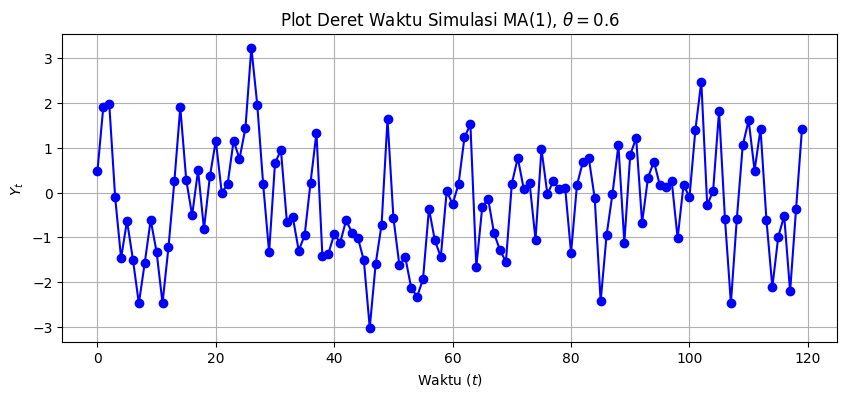

In [ ]:
# Plot deret waktu hasil simulasi
plt.figure(figsize=(10, 4))
plt.plot(y_ma1, marker='o', linestyle='-', color='b')
plt.title('Plot Deret Waktu Simulasi MA(1), $\\theta = 0.6$')
plt.xlabel('Waktu ($t$)')
plt.ylabel('$Y_t$')
plt.grid(True)
plt.show()

Berdasarkan plot, deret waktu MA(1) dengan \(\theta=0,6\) berfluktuasi di sekitar rata-rata yang relatif konstan tanpa menunjukkan tren atau pola musiman. Variansnya juga relatif stabil, sehingga secara visual data menunjukkan karakteristik stasioner.

In [ ]:
# 1. Simulasi deret MA(1) dengan parameter theta = 0.6 dan panjang n = 120

ar_ma1 = [1]
ma_ma1 = [1, 0.6]
ma1_process = ArmaProcess(ar_ma1, ma_ma1)
y_ma1 = ma1_process.generate_sample(nsample=120)


In [ ]:
# 2. Pembagian Data Latih (Train) dan Data Uji (Test)
# Contoh: 80 data pertama untuk latih, 40 data terakhir untuk uji
train_ma1 = y_ma1[:80]
test_ma1 = y_ma1[80:]

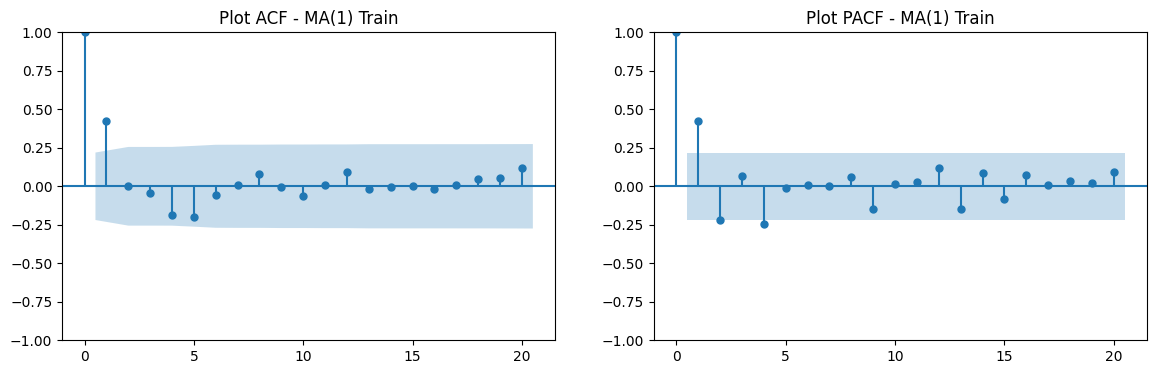

In [ ]:

# 3. Plot ACF, PACF dari data latih
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_ma1, ax=axes[0], lags=20)
axes[0].set_title('Plot ACF - MA(1) Train')
plot_pacf(train_ma1, ax=axes[1], lags=20)
axes[1].set_title('Plot PACF - MA(1) Train')
plt.show()

In [ ]:
# 4. Pengepasan (Fitting) Model ARIMA(0,0,1) dan Diagnostik Sisaan
model_ma1 = ARIMA(train_ma1, order=(0, 0, 1))
results_ma1 = model_ma1.fit()
print(results_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   80
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -110.861
Date:                Wed, 23 Sep 2026   AIC                            227.722
Time:                        04:37:09   BIC                            234.868
Sample:                             0   HQIC                           230.587
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0272      0.178     -0.153      0.878      -0.375       0.321
ma.L1          0.5779      0.112      5.140      0.000       0.358       0.798
sigma2         0.9310      0.148      6.280      0.0

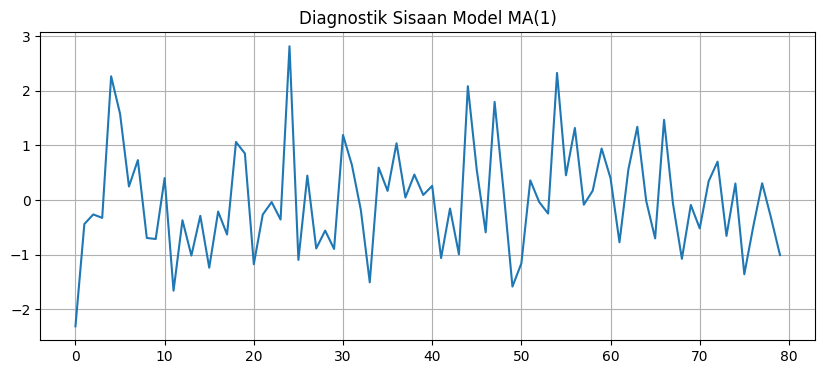

In [ ]:
# Diagnostik Sisaan (Residuals)
residuals_ma1 = results_ma1.resid
plt.figure(figsize=(10, 4))
plt.plot(residuals_ma1)
plt.title('Diagnostik Sisaan Model MA(1)')
plt.grid(True)
plt.show()

In [ ]:
# 5. Peramalan (Forecasting) pada Data Uji
forecast_ma1 = results_ma1.forecast(steps=len(test_ma1))

# Hitung Metrik Evaluasi (MAPE dan RMSE)
def calc_metrics(actual, predicted):
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return rmse, mape

rmse_ma1, mape_ma1 = calc_metrics(test_ma1, forecast_ma1)
print(f"Evaluasi MA(1) - RMSE: {rmse_ma1:.4f}, MAPE: {mape_ma1:.4f}%")

Evaluasi MA(1) - RMSE: 1.2361, MAPE: 101.4177%


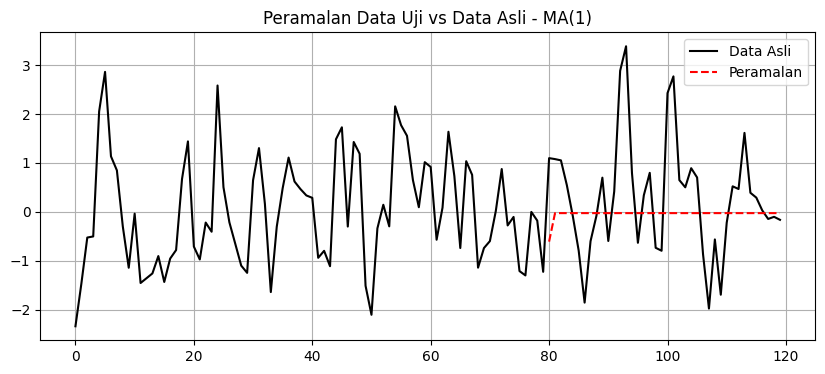

In [ ]:
# Plot Hasil Peramalan vs Data Asli
plt.figure(figsize=(10, 4))
plt.plot(range(len(y_ma1)), y_ma1, label='Data Asli', color='black')
plt.plot(range(80, 120), forecast_ma1, label='Peramalan', color='red', linestyle='--')
plt.title('Peramalan Data Uji vs Data Asli - MA(1)')
plt.legend()
plt.grid(True)
plt.show()

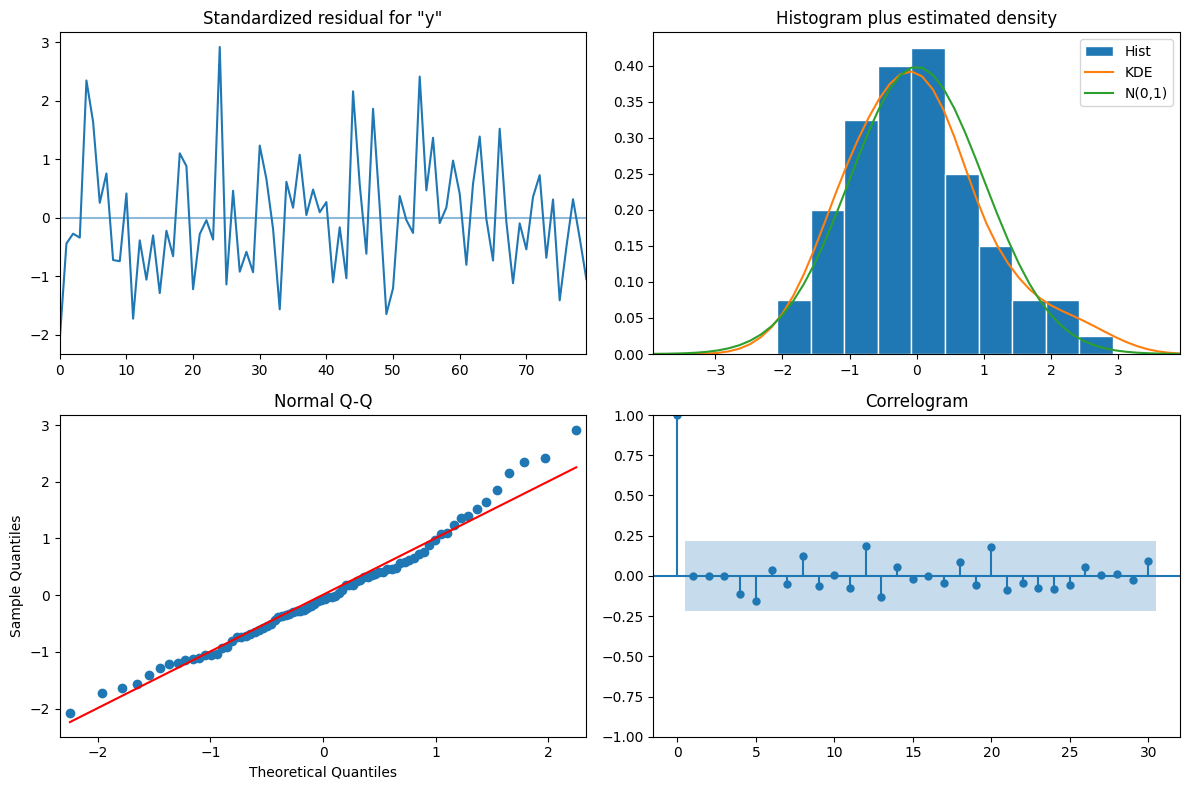

In [ ]:
# #Analisis Sisaan Model
# Pastikan 'results_ma1' adalah objek hasil fitting model (contoh: dari model_ma1.fit())
# Jika menggunakan model lain, ganti 'results_ma1' dengan nama variabel hasil fit model Anda.

fig = results_ma1.plot_diagnostics(figsize=(12, 8), lags=30)
plt.tight_layout()
plt.show()

In [ ]:
# --- Membandingkan Model MA(1) dan MA(2) untuk Cek Overfitting ---

# 1. Fitting Model MA(1) - order=(0,0,1)
model_ma1 = ARIMA(train_ma1, order=(0, 0, 1))
results_ma1 = model_ma1.fit()

# 2. Fitting Model MA(2) - order=(0,0,2) [Penambahan ordo MA]
model_ma2 = ARIMA(train_ma1, order=(0, 0, 2))
results_ma2 = model_ma2.fit()

# 3. Bandingkan Nilai AIC dan BIC
print("=== PERBANDINGAN KRITERIA INFORMASI ===")
print(f"MA(1) -> AIC: {results_ma1.aic:.4f} | BIC: {results_ma1.bic:.4f}")
print(f"MA(2) -> AIC: {results_ma2.aic:.4f} | BIC: {results_ma2.bic:.4f}\n")

# 4. Cek Signifikansi Parameter pada MA(2)
print("=== RINGKASAN PARAMETER MA(2) ===")
print(results_ma2.summary())

=== PERBANDINGAN KRITERIA INFORMASI ===
MA(1) -> AIC: 227.7218 | BIC: 234.8678
MA(2) -> AIC: 229.6938 | BIC: 239.2219

=== RINGKASAN PARAMETER MA(2) ===
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   80
Model:                 ARIMA(0, 0, 2)   Log Likelihood                -110.847
Date:                Wed, 23 Sep 2026   AIC                            229.694
Time:                        04:31:14   BIC                            239.222
Sample:                             0   HQIC                           233.514
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0284      0.182     -0.156      0.876   

#Nomor 6.a - Simulasi Deret AR(2) [φ1 = 0.9, φ2 = −0.5, n = 100]

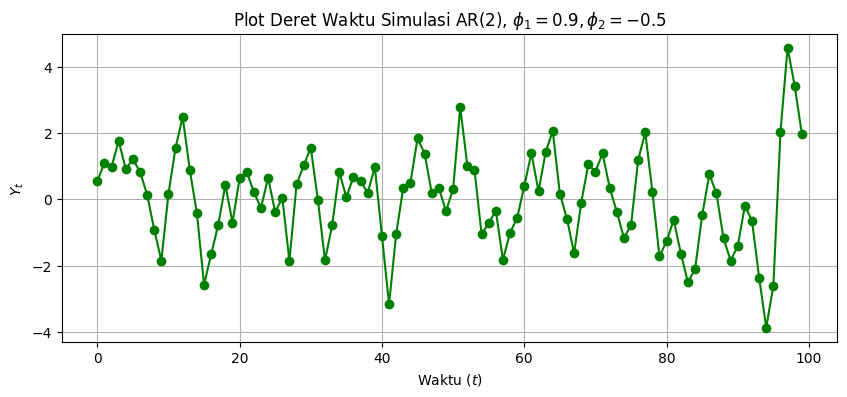

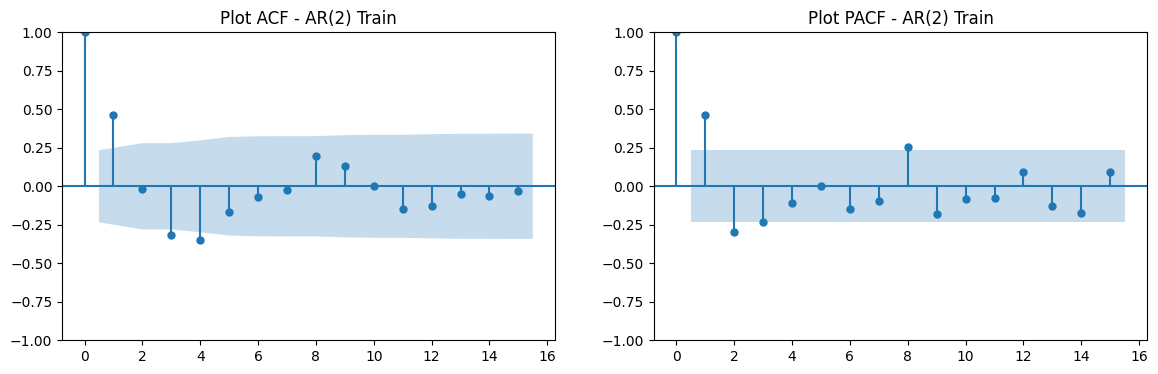

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   70
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 -97.935
Date:                Wed, 23 Sep 2026   AIC                            203.871
Time:                        04:31:19   BIC                            212.865
Sample:                             0   HQIC                           207.443
                                 - 70                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1555      0.175      0.888      0.374      -0.188       0.499
ar.L1          0.6026      0.139      4.350      0.000       0.331       0.874
ar.L2         -0.2972      0.139     -2.143      0.0

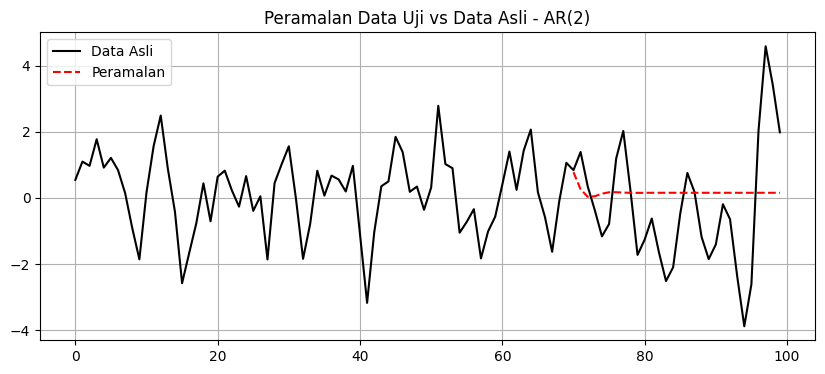

In [ ]:
# 6. Simulasi deret AR(2) dengan n = 100, phi_1 = 0.9, phi_2 = -0.5
# Di statsmodels, parameter AR didefinisikan sebagai [1, -phi_1, -phi_2]
ar_ar2 = [1, -0.9, 0.5]
ma_ar2 = [1]
ar2_process = ArmaProcess(ar_ar2, ma_ar2)
y_ar2 = ar2_process.generate_sample(nsample=100)

# Plot Deret Waktu AR(2)
plt.figure(figsize=(10, 4))
plt.plot(y_ar2, marker='o', linestyle='-', color='g')
plt.title('Plot Deret Waktu Simulasi AR(2), $\\phi_1=0.9, \\phi_2=-0.5$')
plt.xlabel('Waktu ($t$)')
plt.ylabel('$Y_t$')
plt.grid(True)
plt.show()

# Pembagian Data Latih dan Uji (Misal: 70 train, 30 test)
train_ar2 = y_ar2[:70]
test_ar2 = y_ar2[70:]

# Plot ACF & PACF AR(2)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_ar2, ax=axes[0], lags=15)
axes[0].set_title('Plot ACF - AR(2) Train')
plot_pacf(train_ar2, ax=axes[1], lags=15)
axes[1].set_title('Plot PACF - AR(2) Train')
plt.show()

# Fitting Model ARIMA(2,0,0)
model_ar2 = ARIMA(train_ar2, order=(2, 0, 0))
results_ar2 = model_ar2.fit()
print(results_ar2.summary())

# Peramalan & Evaluasi AR(2)
forecast_ar2 = results_ar2.forecast(steps=len(test_ar2))
rmse_ar2, mape_ar2 = calc_metrics(test_ar2, forecast_ar2)
print(f"Evaluasi AR(2) - RMSE: {rmse_ar2:.4f}, MAPE: {mape_ar2:.4f}%")

# Plot Peramalan AR(2)
plt.figure(figsize=(10, 4))
plt.plot(range(len(y_ar2)), y_ar2, label='Data Asli', color='black')
plt.plot(range(70, 100), forecast_ar2, label='Peramalan', color='red', linestyle='--')
plt.title('Peramalan Data Uji vs Data Asli - AR(2)')
plt.legend()
plt.grid(True)
plt.show()

#Nomor 6.b - Simulasi Model ARMA(1,1)

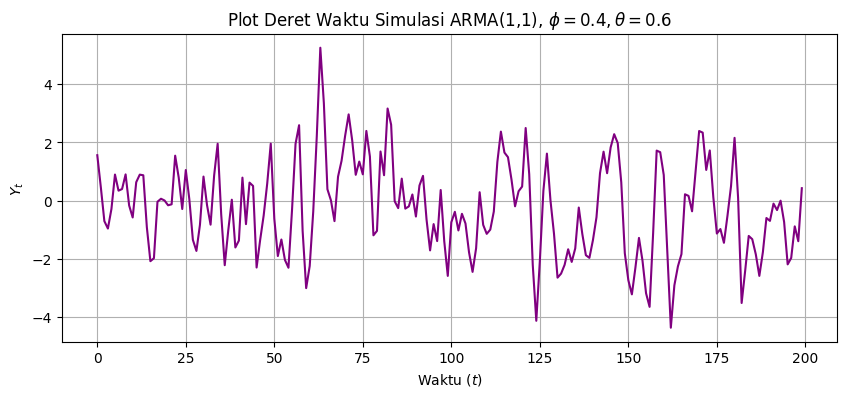

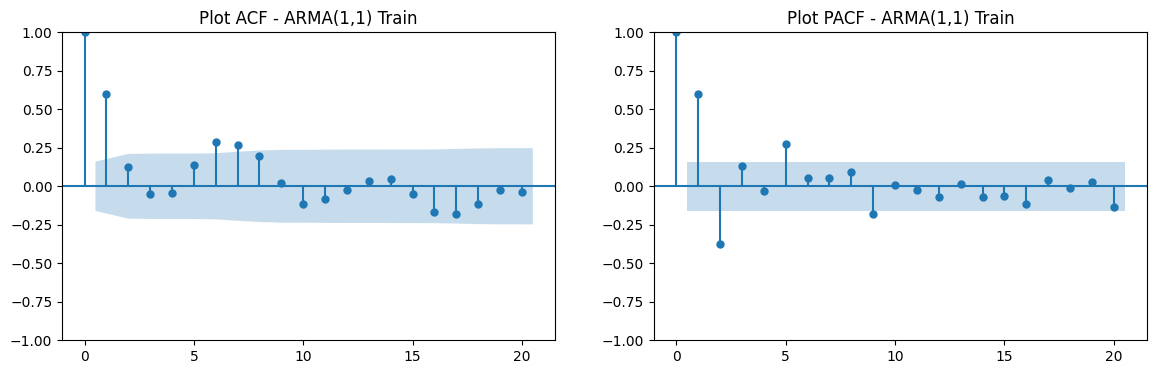

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  150
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -225.659
Date:                Wed, 23 Sep 2026   AIC                            459.318
Time:                        02:57:11   BIC                            471.361
Sample:                             0   HQIC                           464.210
                                - 150                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0755      0.214     -0.353      0.724      -0.494       0.343
ar.L1          0.3086      0.106      2.918      0.004       0.101       0.516
ma.L1          0.6131      0.085      7.175      0.0

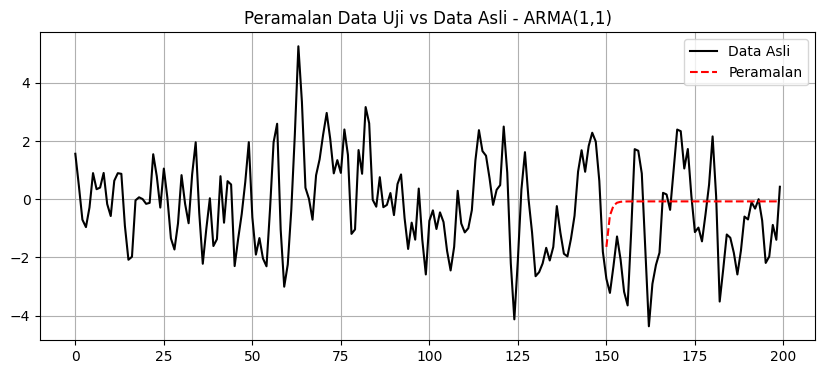

In [ ]:
# 6. Simulasi deret ARMA(1,1) dengan n = 200, phi = 0.4, theta = 0.6
ar_arma11 = [1, -0.4]
ma_arma11 = [1, 0.6]
arma11_process = ArmaProcess(ar_arma11, ma_arma11)
y_arma11 = arma11_process.generate_sample(nsample=200)

# Plot Deret Waktu ARMA(1,1)
plt.figure(figsize=(10, 4))
plt.plot(y_arma11, linestyle='-', color='purple')
plt.title('Plot Deret Waktu Simulasi ARMA(1,1), $\\phi=0.4, \\theta=0.6$')
plt.xlabel('Waktu ($t$)')
plt.ylabel('$Y_t$')
plt.grid(True)
plt.show()

# Pembagian Data Latih dan Uji (Misal: 150 train, 50 test)
train_arma11 = y_arma11[:150]
test_arma11 = y_arma11[150:]

# Plot ACF & PACF ARMA(1,1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_arma11, ax=axes[0], lags=20)
axes[0].set_title('Plot ACF - ARMA(1,1) Train')
plot_pacf(train_arma11, ax=axes[1], lags=20)
axes[1].set_title('Plot PACF - ARMA(1,1) Train')
plt.show()

# Fitting Model ARIMA(1,0,1)
model_arma11 = ARIMA(train_arma11, order=(1, 0, 1))
results_arma11 = model_arma11.fit()
print(results_arma11.summary())

# Peramalan & Evaluasi ARMA(1,1)
forecast_arma11 = results_arma11.forecast(steps=len(test_arma11))
rmse_arma11, mape_arma11 = calc_metrics(test_arma11, forecast_arma11)
print(f"Evaluasi ARMA(1,1) - RMSE: {rmse_arma11:.4f}, MAPE: {mape_arma11:.4f}%")

# Plot Peramalan ARMA(1,1)
plt.figure(figsize=(10, 4))
plt.plot(range(len(y_arma11)), y_arma11, label='Data Asli', color='black')
plt.plot(range(150, 200), forecast_arma11, label='Peramalan', color='red', linestyle='--')
plt.title('Peramalan Data Uji vs Data Asli - ARMA(1,1)')
plt.legend()
plt.grid(True)
plt.show()